# News alerts - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 11:00.** You drive a coding agent (Codex, Claude Code, or
Antigravity CLI). Paste each prompt, run the code, apply the check.


## About this data source

Four ways the world learns about an outbreak *before the data exists*, in order of how
easily we can use them:

- **GDELT** indexes world news in 100+ languages and gives it away through a free API with
  **no key**, which is why it is the one we scrape in class.
  **Explore:** <https://www.gdeltproject.org/>
- **HealthMap** reads news and official reports automatically and pins them on a world map.
  **Explore:** <https://www.healthmap.org/>
- **ProMED** is the opposite: real human experts posting curated outbreak reports since 1994.
  It flagged COVID about a day before the official notice. **Explore:**
  <https://promedmail.org/>
- **Media Cloud** is the scholars' media-analysis tool: **200M+ stories** in curated
  *collections* (national presses, country sets), built for studying *how* a topic is
  covered. Needs a **free API key**, so here it is a bonus rather than the main path.
  **Explore:** <https://search.mediacloud.org/>

> Open HealthMap and zoom to a region (every dot is a report), then read one ProMED post, to
> feel the difference between an automated map and a curated expert alert. Media Cloud shows
> you a third thing: attention over time, by outlet.

**The trade-off worth naming:** GDELT is *breadth with no key*; Media Cloud is *curation
with a key*. That is the same pattern as OpenSky vs OpenFlights, and Facebook posts vs the
Facebook symptom survey.


## Step 1: scan the news

> *Using the GDELT DOC 2.0 API (free, no key), find news articles from the past month*
> *that mention dengue outbreaks. Return a tidy table with date, source country, domain,*
> *headline and URL, and report how many articles and the date range.*


In [1]:
# Agent's GDELT scan:
import json
import os
import urllib.parse
import urllib.request

import pandas as pd

query = 'dengue outbreak'
url = (
    'https://api.gdeltproject.org/api/v2/doc/doc'
    f'?query={urllib.parse.quote(query)}&mode=artlist&maxrecords=250'
    '&format=json&timespan=1m'
)

try:
    request = urllib.request.Request(
        url, headers={'User-Agent': 'SISMID2026-course/1.0'}
    )
    with urllib.request.urlopen(request, timeout=120) as response:
        articles = json.loads(response.read()).get('articles', [])
    news = pd.DataFrame([{
        'date': article.get('seendate', ''),
        'source_country': article.get('sourcecountry', ''),
        'domain': article.get('domain', ''),
        'headline': (article.get('title') or '').strip(),
        'url': article.get('url', ''),
    } for article in articles])
    if news.empty:
        raise RuntimeError('GDELT returned no articles')
except Exception as error:
    # The cached snapshot keeps the exercise runnable offline or when rate-limited.
    for path in ('../data/gdelt_dengue_articles.csv', 'data/gdelt_dengue_articles.csv'):
        if os.path.exists(path):
            news = pd.read_csv(path).rename(columns={
                'seendate': 'date', 'sourcecountry': 'source_country', 'title': 'headline'
            })
            print(f'Live GDELT pull failed: {error}; using {path}')
            break
    else:
        raise

news['date'] = pd.to_datetime(news['date'], format='%Y%m%dT%H%M%SZ', errors='coerce')
news = news[['date', 'source_country', 'domain', 'headline', 'url']].sort_values('date', ascending=False)
print(f'{len(news)} articles; {news.date.min()} to {news.date.max()}')
news.head(10)


Live GDELT pull failed: HTTP Error 429: Too Many Requests; using ../data/gdelt_dengue_articles.csv
231 articles; 2026-06-20 19:00:00 to 2026-07-20 16:15:00


,date,source_country,domain,headline,url
60,2026-07-20 16:15:00,Nigeria,premiumtimesng.com,Half of approved diagnostics for Africa priori...,https://www.premiumtimesng.com/health/health-n...
64,2026-07-20 16:15:00,Sri Lanka,lankanewspapers.com,Sri Lanka Dengue Crisis Deepens as Reported Ca...,https://www.lankanewspapers.com/2026/07/20/sri...
76,2026-07-20 15:45:00,NaN,arabnet5.com,الهند تحصل على أول لقاح ضد حمى الضنك,https://www.arabnet5.com/news/%C7%E1%E5%E4%CF-...
165,2026-07-20 12:45:00,Nigeria,opinionnigeria.com,WHO Mediterranean Office calls for $6 . 42 mil...,https://www.opinionnigeria.com/who-mediterrane...
77,2026-07-20 07:00:00,Sri Lanka,lankanewspapers.com,Sri Lanka Dengue Crisis Deepens as Cases Breac...,https://www.lankanewspapers.com/2026/07/20/sri...
10,2026-07-19 22:45:00,Israel,aljazeera.net,حمى الضنك تجتاح الدمازين السودانية .. آلاف الإ...,https://www.aljazeera.net/politics/2026/7/20/%...
170,2026-07-19 22:30:00,Libya,libyaakhbar.com,من جمهورية الموز إلى مقبرة الضمير .. كيف يح...,https://www.libyaakhbar.com/libya-news/2838407...
101,2026-07-19 12:30:00,United States,arstechnica.com,"As mosquito ranges expand , better monitoring ...",https://arstechnica.com/science/2026/07/as-mos...
109,2026-07-19 05:15:00,Australia,watoday.com.au,Mosquito alarm : AI device detecting the world...,https://www.watoday.com.au/national/nsw/the-de...
120,2026-07-18 14:45:00,Yemen,alwahdawi.net,خارطة أوبئة تضغط على منظومة صحية منهكة في اليمن,https://alwahdawi.net/news-38569


## Step 2: emerging-outbreak watch

> *Tally the articles by source country and plot the top 12, then plot article volume*
> *per day. Summarise which countries are newly reporting activity.*

**Your check:** is a spike a real outbreak, or one wire story syndicated everywhere?


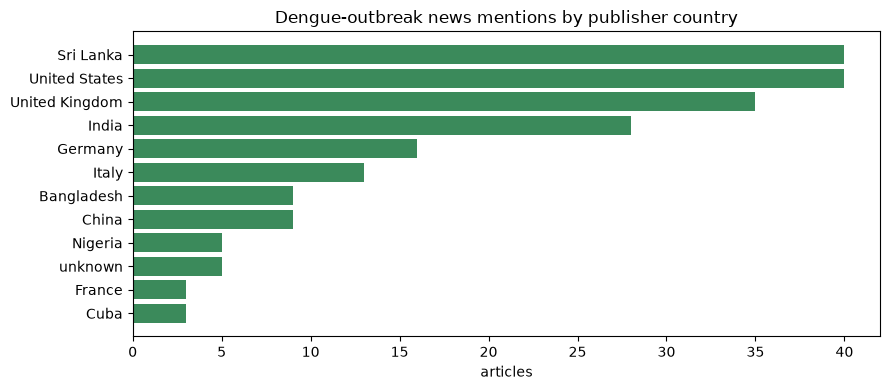

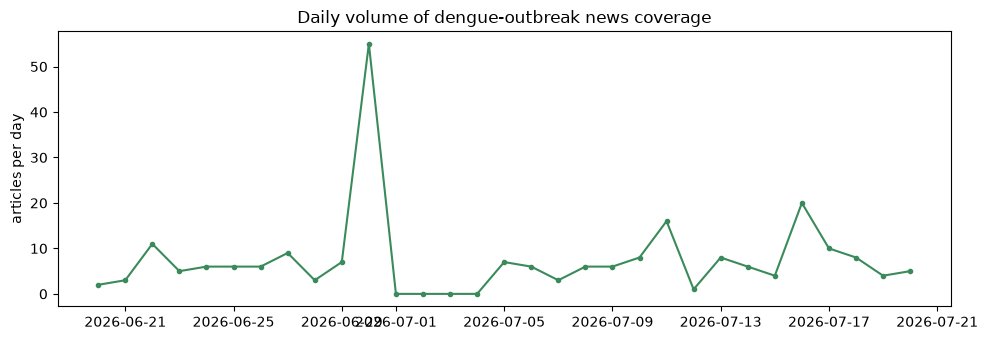

Top publisher countries:


,articles
source_country,
Sri Lanka,40
United States,40
United Kingdom,35
India,28
Germany,16
Italy,13
Bangladesh,9
China,9
Nigeria,5



Interpretation: this reports where articles were published, not where dengue cases occurred. A rise can be genuine new reporting, but it can also be syndication of one wire story; check repeated headlines and URLs before calling it an outbreak signal.


In [2]:
# Agent's country tally + volume plot:
import matplotlib.pyplot as plt

top_countries = news['source_country'].fillna('unknown').replace('', 'unknown').value_counts().head(12)

plt.figure(figsize=(9, 4))
plt.barh(top_countries.index[::-1], top_countries.values[::-1], color='#3B8A5B')
plt.xlabel('articles')
plt.title('Dengue-outbreak news mentions by publisher country')
plt.tight_layout()
plt.show()

daily_articles = news.set_index('date').resample('D').size()
plt.figure(figsize=(10, 3.5))
plt.plot(daily_articles.index, daily_articles.values, marker='o', ms=3, color='#3B8A5B')
plt.ylabel('articles per day')
plt.title('Daily volume of dengue-outbreak news coverage')
plt.tight_layout()
plt.show()

print('Top publisher countries:')
display(top_countries.to_frame('articles'))
print(
    '\nInterpretation: this reports where articles were published, not where dengue cases occurred. '
    'A rise can be genuine new reporting, but it can also be syndication of one wire story; '
    'check repeated headlines and URLs before calling it an outbreak signal.'
)


## Step 3: sanity-check and save

> *Report article count, unique domains, and how many duplicate headlines there are*
> *(syndication). Save a tidy CSV and print the five most recent headlines.*


In [3]:
# Agent's checks + save:
from pathlib import Path

duplicate_headlines = int(news['headline'].duplicated().sum())
print(f'articles:           {len(news)}')
print(f'unique domains:     {news["domain"].nunique()}')
print(f'duplicate headlines:{duplicate_headlines} (possible syndication)')

# Keep a reusable, explicitly tidy version with the fields requested in Step 1.
output_dir = Path('../data') if Path('../data').is_dir() else Path('data')
output_dir.mkdir(exist_ok=True)
output_path = output_dir / 'news_outbreak_watch.csv'
news.to_csv(output_path, index=False)
print(f'\nsaved tidy CSV: {output_path}')

print('\nfive most recent headlines:')
for _, article in news.head(5).iterrows():
    country = article.source_country if pd.notna(article.source_country) else 'unknown'
    print(f'- {article.date:%Y-%m-%d} | {country} | {article.headline}')


articles:           231
unique domains:     167
duplicate headlines:73 (possible syndication)

saved tidy CSV: ../data/news_outbreak_watch.csv

five most recent headlines:
- 2026-07-20 | Nigeria | Half of approved diagnostics for Africa priority epidemic diseases unavailable at primary healthcare level – Report
- 2026-07-20 | Sri Lanka | Sri Lanka Dengue Crisis Deepens as Reported Cases Exceed 76 , 000
- 2026-07-20 | unknown | الهند تحصل على أول لقاح ضد حمى الضنك
- 2026-07-20 | Nigeria | WHO Mediterranean Office calls for $6 . 42 million to sustain health and nutrition services across Somalia , Sudan and Djibouti - By Kelvin Kwame Dewey
- 2026-07-20 | Sri Lanka | Sri Lanka Dengue Crisis Deepens as Cases Breach 76 , 000 Mark Before July End


## Bonus: Media Cloud (needs a free API key)

> *Media Cloud indexes 200M+ news stories in curated collections and has a Python client*
> *(`pip install mediacloud`). Using mediacloud.api.SearchApi with my MEDIACLOUD_API_KEY*
> *environment variable, pull stories from the last 30 days matching my query in the US*
> *national collection (id 34412234), and show publish date, outlet and headline. If the key*
> *is not set, skip cleanly and tell me GDELT already covered it.*

Get a free key by signing up at <https://search.mediacloud.org/>. Compare what Media Cloud
returns against GDELT: curated collections versus raw breadth.


In [4]:
# Agent's Media Cloud pull (optional, needs MEDIACLOUD_API_KEY):
# Install once in your environment: pip install mediacloud
import os
from datetime import date, timedelta

media_cloud_key = os.environ.get('MEDIACLOUD_API_KEY')
us_national_collection = 34412234

if not media_cloud_key:
    print('MEDIACLOUD_API_KEY is not set; skipping Media Cloud.')
    print('GDELT above already provides the no-key, broad-coverage path.')
else:
    try:
        import mediacloud.api
    except ImportError:
        print('Install the optional client with: pip install mediacloud')
    else:
        end_date = date.today()
        start_date = end_date - timedelta(days=30)
        try:
            media_cloud = mediacloud.api.SearchApi(media_cloud_key)
            stories, _ = media_cloud.story_list(
                query, start_date=start_date, end_date=end_date,
                collection_ids=[us_national_collection],
            )
        except Exception as error:
            print(f'Media Cloud request failed: {error}')
            print('GDELT above already provides the no-key, broad-coverage path.')
        else:
            media_cloud_news = pd.DataFrame(stories)
            print(f'Media Cloud: {len(media_cloud_news)} stories on the first page.')
            columns = [c for c in ['publish_date', 'media_name', 'title'] if c in media_cloud_news]
            display(media_cloud_news[columns].rename(columns={'media_name': 'outlet', 'title': 'headline'}).head(10))
            print('Compare: Media Cloud is a curated US collection; GDELT is broader, global news coverage.')


## Reflection

- News catches what has no data stream yet; it needs a human read.
- **Stretch:** swap in your own disease and region, and try `TIMESPAN='1w'`.
